In [1]:
import os

print(os.getcwd())
print(os.listdir("../data"))

C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\Notebook
['bluestock_mf.db', 'processed', 'Raw']


In [2]:
import os
os.listdir("C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'hdfc_top100_nav.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [3]:
import pandas as pd

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
print(nav.info())
print(nav.describe())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None
           amfi_code           nav
count   46000.000000  46000.000000
mean   120247.000000    269.570265
std     14352.317221    577.187060
min    100016.000000     26.136600
25%    118632.750000     69.170425
50%    119551.500000    122.732150
75%    120842.250000    260.338675
max    149324.000000   4268.549700


In [5]:
print(nav.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64


In [6]:
nav['date'] = pd.to_datetime(nav['date'])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


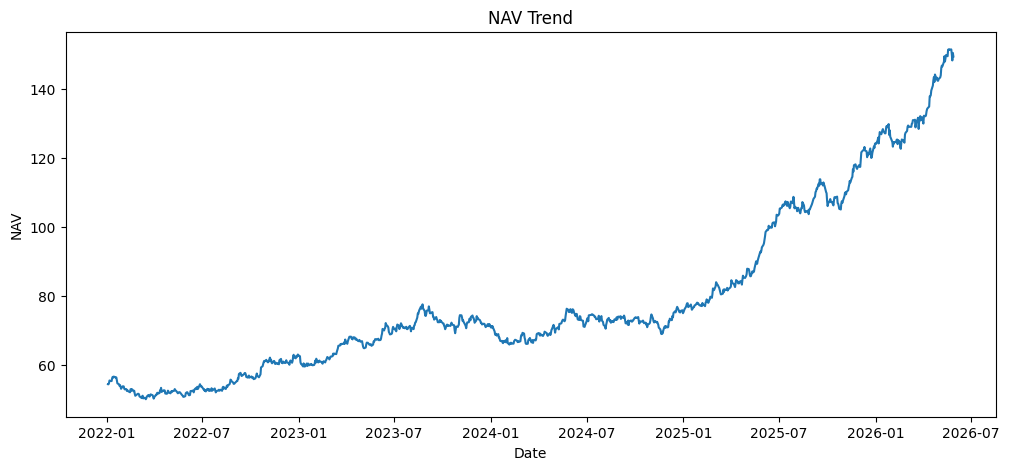

In [7]:
import matplotlib.pyplot as plt

sample_fund = nav[nav['amfi_code'] == nav['amfi_code'].iloc[0]]

plt.figure(figsize=(12,5))
plt.plot(sample_fund['date'], sample_fund['nav'])

plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

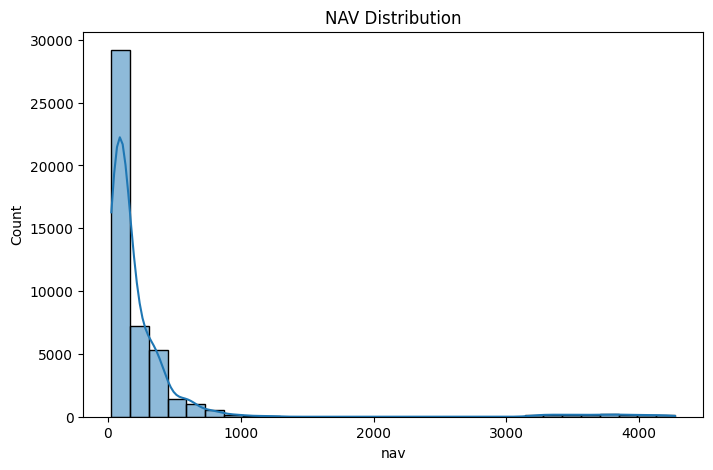

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(nav['nav'], bins=30, kde=True)

plt.title("NAV Distribution")
plt.show()

In [9]:
nav.sort_values('nav', ascending=False).head()

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
27598,120844,2026-05-28,4266.9021
27597,120844,2026-05-27,4264.9256
27596,120844,2026-05-26,4262.3302
27594,120844,2026-05-22,4260.3220


In [10]:
print("Start Date:", nav['date'].min())
print("End Date:", nav['date'].max())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00


In [11]:
print("Total Funds:", nav['amfi_code'].nunique())

Total Funds: 40


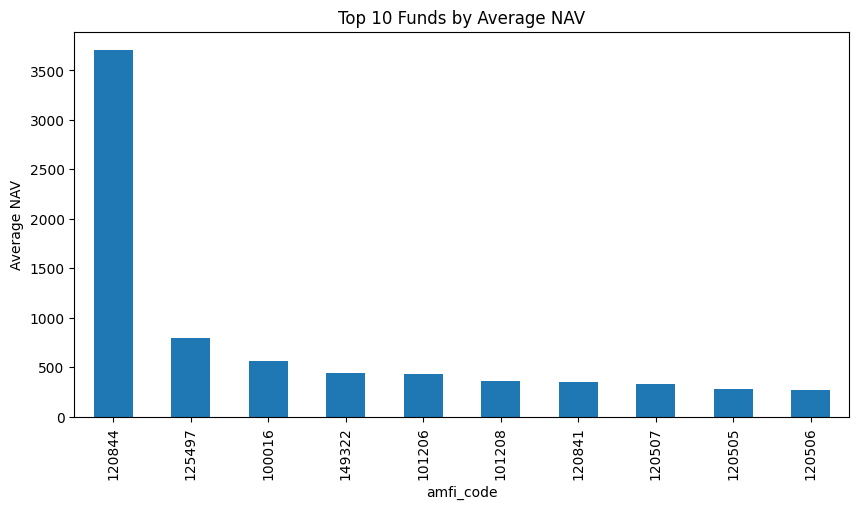

In [12]:
avg_nav = nav.groupby('amfi_code')['nav'].mean().sort_values(ascending=False).head(10)

avg_nav.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Funds by Average NAV")
plt.ylabel("Average NAV")
plt.show()

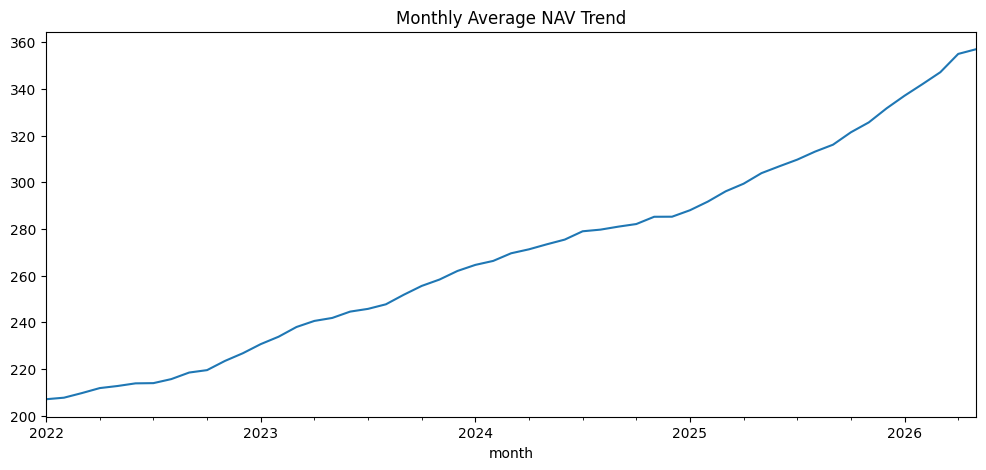

In [13]:
nav['month'] = nav['date'].dt.to_period('M')

monthly_nav = nav.groupby('month')['nav'].mean()

monthly_nav.plot(figsize=(12,5))
plt.title("Monthly Average NAV Trend")
plt.show()

In [ ]:
EDA Summary

1. Dataset contains 46,000 NAV records.
2. No missing values found in key columns.
3. NAV values range from approximately 26 to 4268.
4. Multiple mutual fund schemes are present.
5. NAV trend shows long-term growth with short-term fluctuations.
6. Data covers multiple years and is suitable for performance analysis.

In [1]:
import pandas as pd

aum = pd.read_csv("C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [2]:
import pandas as pd

aum = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/03_aum_by_fund_house.csv"
)

print(aum.head())
print(aum.columns.tolist())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [3]:
sip = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/04_monthly_sip_inflows.csv"
)

print(sip.head())
print(sip.columns.tolist())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [4]:
category = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/05_category_inflows.csv"
)

print(category.head())
print(category.columns.tolist())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
['month', 'category', 'net_inflow_crore']


In [5]:
investor = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/08_investor_transactions.csv"
)

print(investor.head())
print(investor.columns.tolist())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [6]:
portfolio = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/09_portfolio_holdings.csv"
)

print(portfolio.head())
print(portfolio.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [7]:
import pandas as pd

aum = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/03_aum_by_fund_house.csv"
)

print(aum.head())
print(aum.columns.tolist())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [8]:
portfolio = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/09_portfolio_holdings.csv"
)

print(portfolio.head())
print(portfolio.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [9]:
import pandas as pd

aum = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/03_aum_by_fund_house.csv"
)

print(aum.head())
print(aum.columns.tolist())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


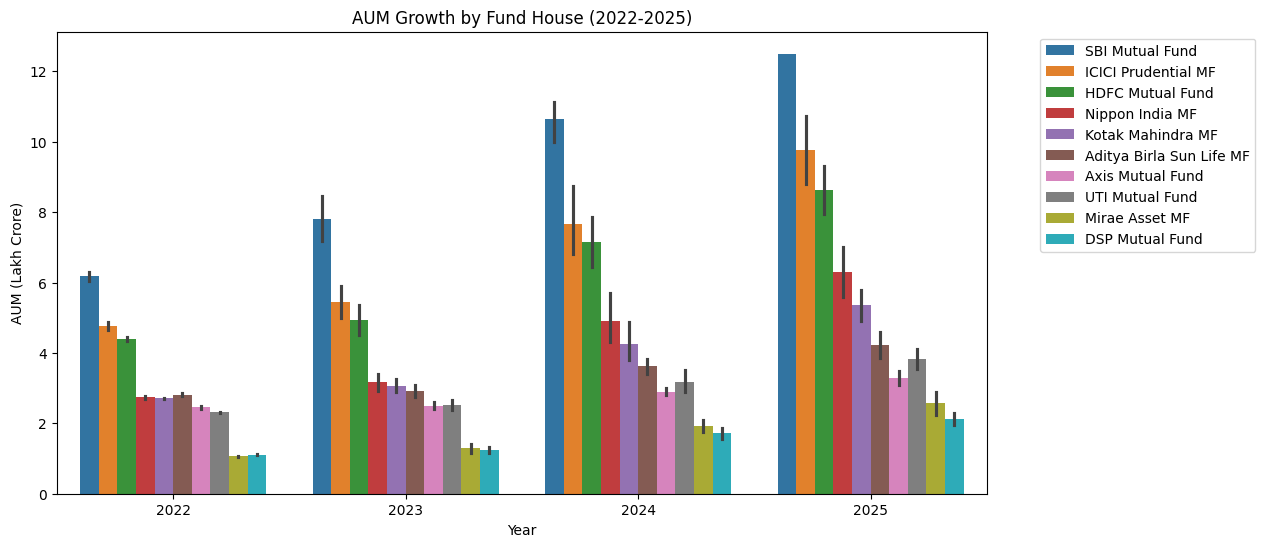

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

In [11]:
aum.sort_values('aum_lakh_crore', ascending=False).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
71,2025-03-31,ICICI Prudential MF,8.80,880000,216,2025
61,2024-12-31,ICICI Prudential MF,8.74,874000,216,2024
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023


In [12]:
sip = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/04_monthly_sip_inflows.csv"
)

print(sip.head())
print(sip.columns.tolist())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [13]:
category = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/05_category_inflows.csv"
)

print(category.head())
print(category.columns.tolist())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
['month', 'category', 'net_inflow_crore']


In [14]:
investor = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/08_investor_transactions.csv"
)

print(investor.head())
print(investor.columns.tolist())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

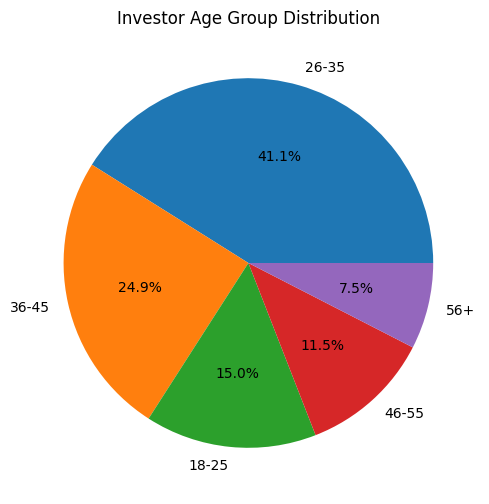

In [15]:
import matplotlib.pyplot as plt

age_counts = investor['age_group'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title("Investor Age Group Distribution")
plt.show()

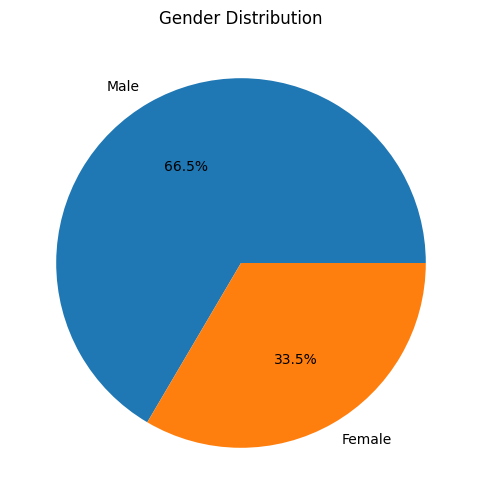

In [16]:
gender_counts = investor['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

In [18]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


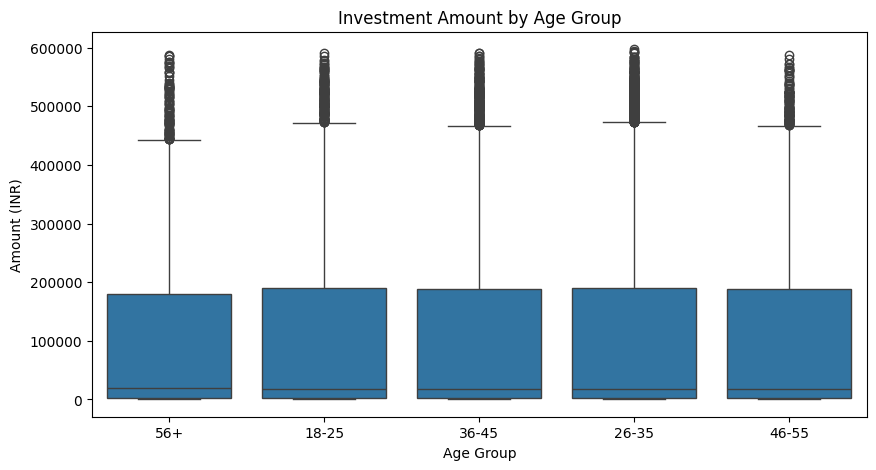

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.show()

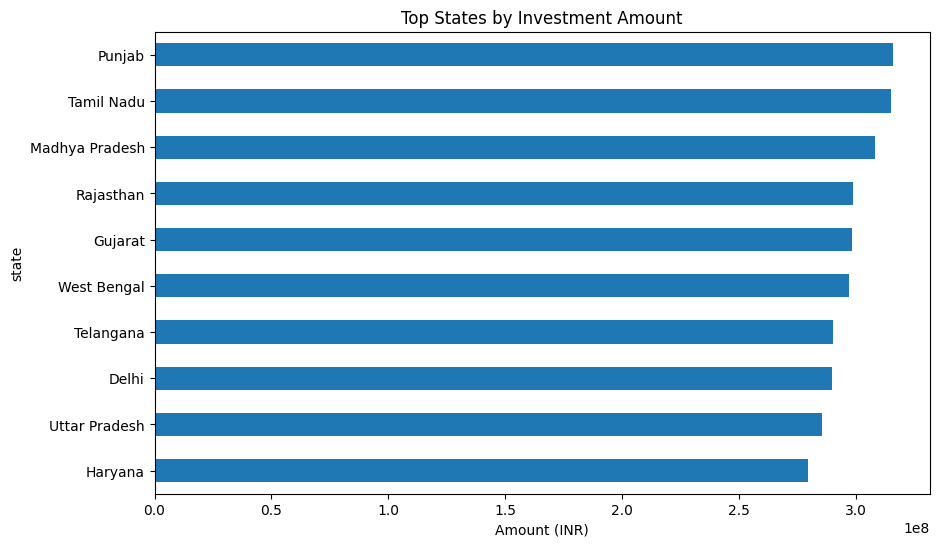

In [20]:
state_amount = investor.groupby('state')['amount_inr'].sum()

state_amount.sort_values().tail(10).plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top States by Investment Amount")
plt.xlabel("Amount (INR)")
plt.show()

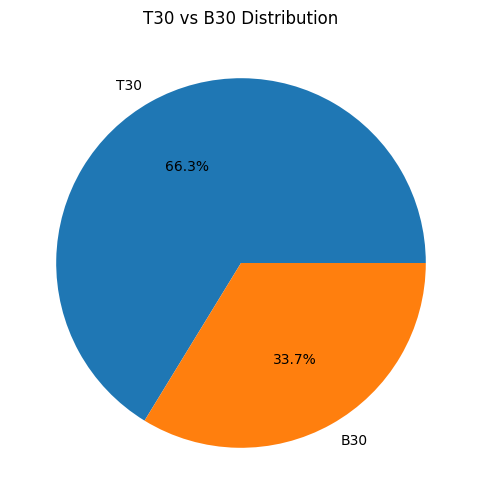

In [21]:
tier_counts = investor['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Distribution")
plt.show()

In [22]:
folio = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/06_industry_folio_count.csv"
)

print(folio.head())
print(folio.columns.tolist())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [24]:
import pandas as pd

folio = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/06_industry_folio_count.csv"
)

print(folio.head())
print(folio.columns.tolist())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [25]:
print(folio.head())
print(folio.columns.tolist())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


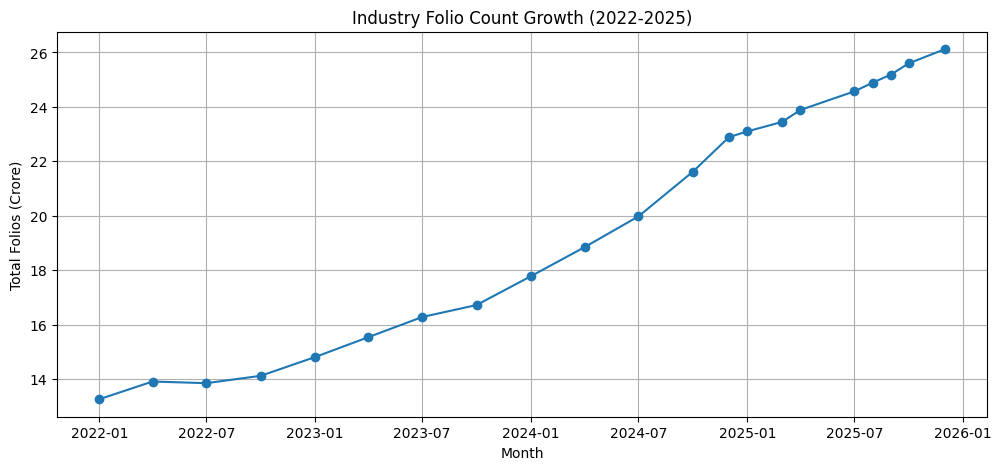

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

In [27]:
print(
    "Start:",
    folio['total_folios_crore'].min(),
    "Crore"
)

print(
    "End:",
    folio['total_folios_crore'].max(),
    "Crore"
)

Start: 13.26 Crore
End: 26.12 Crore


In [29]:
import pandas as pd

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [30]:
nav['date'] = pd.to_datetime(nav['date'])

top_funds = nav['amfi_code'].unique()[:10]

corr_data = nav[
    nav['amfi_code'].isin(top_funds)
]

pivot_df = corr_data.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot_df.pct_change()

corr_matrix = returns.corr()

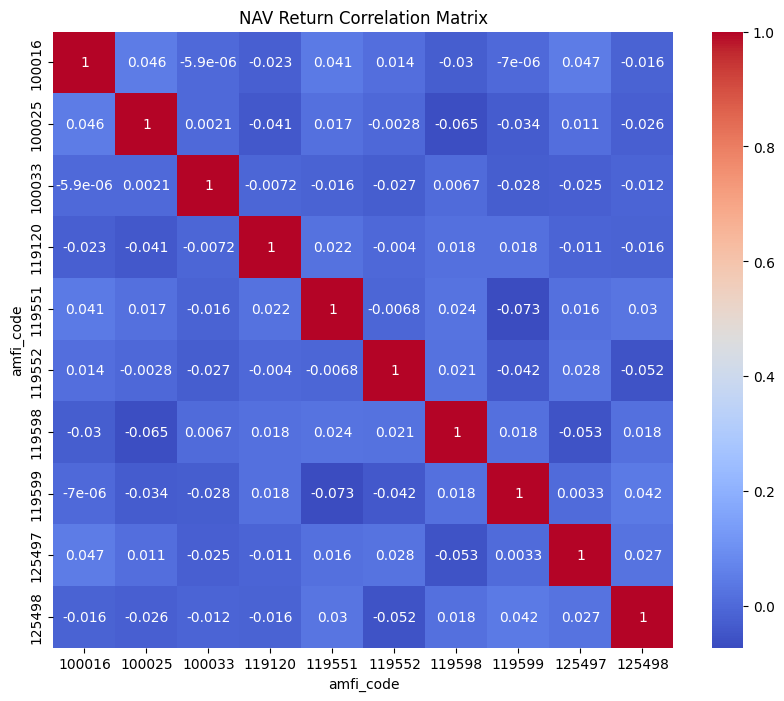

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [32]:
portfolio = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/09_portfolio_holdings.csv"
)

print(portfolio.head())
print(portfolio.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [33]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


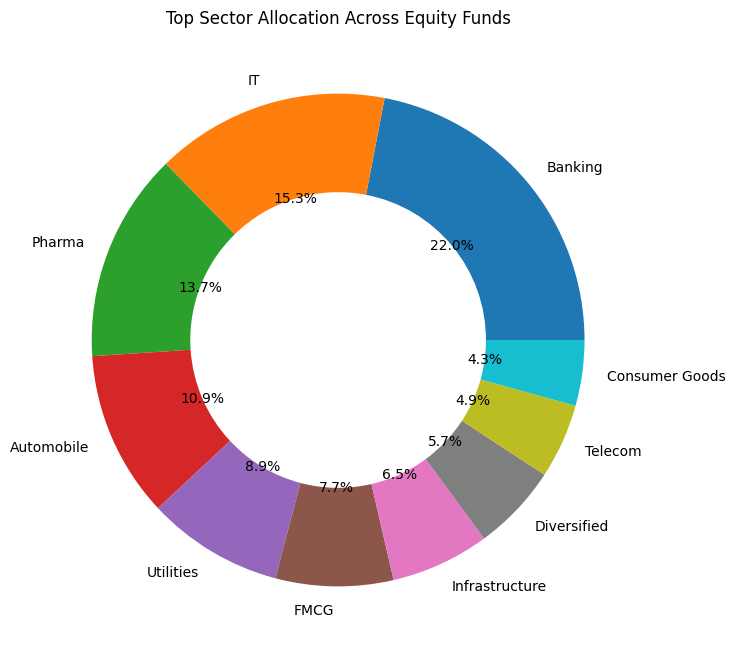

In [34]:
sector_alloc = portfolio.groupby('sector')['weight_pct'].sum()

top_sectors = sector_alloc.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_sectors,
    labels=top_sectors.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Top Sector Allocation Across Equity Funds")

plt.show()